## IIP314W Optimización aplicada a negocios

Visualización espacio de decisión

### Optimización con restricciones

Ahora vamos a agregarle a nuestro problema de optimización restricciones de desigualdad, veamoslo gráficamente.

#### Ejercicio 1

$$ min \left( -x - 2 y \right) $$

Con $x \geq 0$ e $y \geq 0$, sujeto a:

$$ R_1: 2x + 6 y \leq 36 $$
$$ R_2: 5x + 3 y \leq 30 $$
$$ R_3: 8x + 2 y \leq 40 $$
Grafiquemos las restricciones (solución sencilla).

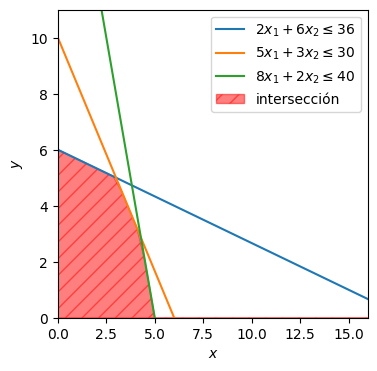

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.close('all')
x = np.linspace(0, 20)
r1 = (36 - 2 * x) / 6
r2 = (30 - 5 * x) / 3
r3 = (40 - 8 * x) / 2

plt.figure(figsize=(4,4))
plt.plot(x, r1, label=r'$2 x_{1} + 6 x_{2}\leq 36$')
plt.plot(x, r2, label=r'$5 x_{1} + 3 x_{2}\leq 30$')
plt.plot(x, r3, label=r'$8 x_{1} + 2 x_{2}\leq 40$')
plt.xlim((0, 16))
plt.ylim((0, 11))
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.fill_between(x, 0, np.minimum(np.minimum(r1,r2),r3), color='red', alpha=0.5, hatch='//',
                 interpolate=True, label='intersección')
plt.legend()
plt.show()

Ahora incorporemos la función objetivo.

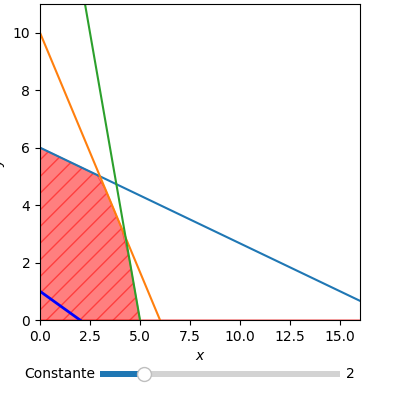

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
%matplotlib widget

plt.close('all')

def create_movable_line_plot():
    initial = 2
    
    # Create the figure and a single subplot
    fig = plt.figure(figsize=(4, 4))
    plt.subplots_adjust(left=0.1, bottom=0.2, top=.99, right=.9)

    # Define the x-range for the line
    x = np.linspace(0, 20)

    # funcion objetivo y restricciones
    r1 = (36 - 2 * x) / 6
    r2 = (30 - 5 * x) / 3
    r3 = (40 - 8 * x) / 2
    obj = (- x + initial) / 2

    plt.xlim((0, 16))
    plt.ylim((0, 11))
    plt.xlabel(r'$x$')
    plt.ylabel(r'$y$')
    plt.plot(x, r1, label=r'$2 x_{1} + 6 x_{2}\leq 36$')
    plt.plot(x, r2, label=r'$5 x_{1} + 3 x_{2}\leq 30$')
    plt.plot(x, r3, label=r'$8 x_{1} + 2 x_{2}\leq 40$')
    plt.fill_between(x, 0, np.minimum(np.minimum(r1,r2),r3), color='red', alpha=0.5, hatch='//',
                 interpolate=True, label='intersección')
    line, = plt.plot(x, obj, lw=2, color='blue') # 'line,' is important for updating the plot

    # reservo espacio para el slider
    ax_sp = plt.axes([0.25, 0.05, 0.6, 0.03], facecolor='lightgray') # x, y, width, height
    s_const = Slider(ax_sp, 'Constante', -2.0, 20.0, valinit=initial)

    # actualiza la recta de la funcion objetivo
    def update(val):
        current_sl = s_const.val
        new_obj = (- x + current_sl) / 2
        line.set_ydata(new_obj)
        fig.canvas.draw_idle()

    s_const.on_changed(update)
    plt.show()

create_movable_line_plot()

Pregunta: ¿Qué pasa si eliminamos la tercera restricción al problema?, en este caso la restricción no es *activa* en el optimo.

Una visualización mas compleja, que pasa si cambiamos la restricción 2 de *signo*, damos vuelta la inecuación

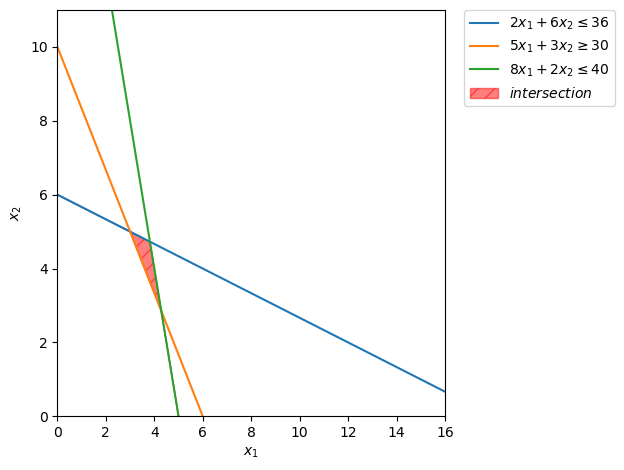

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.close('all')
x = np.linspace(0, 20, 2000)
y1 = (36 - 2 * x) / 6
y2 = (30 - 5 * x) / 3
y3 = (40 - 8 * x) / 2

plt.plot(x, y1, label=r'$2 x_{1} + 6 x_{2}\leq 36$')
plt.plot(x, y2, label=r'$5 x_{1} + 3 x_{2}\geq 30$')
plt.plot(x, y3, label=r'$8 x_{1} + 2 x_{2}\leq 40$')
plt.xlim((0, 16))
plt.ylim((0, 11))
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')

#plt.fill_between(x, y1, y2, color='grey', alpha=0.5,
#                 interpolate=True)
plt.fill_between(x, np.minimum(np.minimum(y1, y2),y3), np.minimum(y1, y3), color='red', alpha=0.5, hatch='//',
                 interpolate=True, label='$intersection$')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

En la última figura, las restricciones de no negatividad son *redundantes*, es decir no restringe el espacio de decisión.

Como usaban GeoGebra, pueden investigar como hacerlo ahí.

Próxima clase condiciones KKT (Karush Kuhn Tucker), son un conjunto de condiciones matemáticas que, cuando se cumplen, garantizan encontrar la solución a un problema de optimización no lineal con restricciones. Es una generalización del método de los multiplicadores de Lagrange que permite incorporar restricciones de igualdad y desigualdad.

Revisar para el jueves los siguientes videos:

https://www.youtube.com/watch?v=fP_Me0-dfJI

https://www.youtube.com/watch?v=kAXnkzEXEV4